Not used in the paper, but yields qualitatively the same results as (R01-2)
with a larger window size (5 kbp -> 10 kbp).

# IS insertion ~ essential genes
Previously (ipynb: 02) I analyzed the significance of the correlation
between the number of essential genes and the number of IS insertions.
Here, according to the reviewer, I will analyze

IS insertion ~ pre-existing IS + essential genes + round

The previous analysis used the data of mapping onto MDS42 genome.
The distribution of IS is meaningless because there was only one IS in the strain.

Here, I compare either with the previous sequencing round, or with the FACS generation.

## Comparison with the FACS generated ancestor
- count the number of essential genes in each window 
- count the number of IS insertions in each window

In [1]:
import Pkg
using RCall
using Random
using DataFrames, DataFramesMeta, Chain
using Revise
using CSV
using StatsBase
using Statistics
using Arrow

R"""
Sys.setlocale("LC_COLLATE","C") # order by dictionary order
library(tidyverse)
library(cowplot)
library(latex2exp)
library(stats)
library(scales)
library(lemon)
library(gghalves)
library(ggbeeswarm)
library(ggpointdensity)
library(viridis)
library(forcats)
library(MASS)
library(sfsmisc)
library(ggnewscale)
library(ggrastr)
library(car)
library(arrow)
library(performance)
library(pscl)
cbp <- c("#999999", "#E69F00", "#56B4E9", "#009E73", 
                       "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
select <- dplyr::select
filter <- dplyr::filter
lag <- dplyr::lag
""";

┌ Warning: RCall.jl: ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
│ ✔ dplyr     1.1.3     ✔ readr     2.1.4
│ ✔ forcats   1.0.0     ✔ stringr   1.5.0
│ ✔ ggplot2   3.4.3     ✔ tibble    3.2.1
│ ✔ lubridate 1.9.2     ✔ tidyr     1.3.0
│ ✔ purrr     1.0.2     
│ ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
│ ✖ dplyr::filter() masks stats::filter()
│ ✖ dplyr::lag()    masks stats::lag()
│ ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘cowplot’
│ 
│ The following object is masked from ‘package:lubridate’:
│ 
│     stamp
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘scales’
│ 
│ The following object is masked from ‘package:purrr’:
│ 
│     discard
│ 
│ The following object is masked from ‘package:readr’:
│ 
│     co

In [2]:
R"""
base_dir = file.path("exp", "multiple_runs14")
exp_dir = file.path(base_dir, "export", "classify_IS_events")
dat_dir = file.path(base_dir, "data", "ins_del_analysis")
fig_dir = file.path(base_dir, "figs", "R01_INS_ESS_corr")
tmp_dir = file.path(base_dir, "tmp", "R01_INS_ESS_corr")
file_name_base = "20250204_"

dir.create(fig_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(tmp_dir, showWarnings = FALSE, recursive = TRUE)

ess_pos_df <- read_csv(file.path(dat_dir, paste0(file_name_base, "essential_gene_pos.csv")))
ess_pos_df %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 40045 Columns: 15
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (2): gene, line
│ dbl (12): pident, length, mismatch, gapopen, qstart, qend, sstart, send, eva...
│ lgl  (1): duplicated
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 15
  gene  pident length mismatch gapopen qstart  qend  sstart    send evalue
  <chr>  <dbl>  <dbl>    <dbl>   <dbl>  <dbl> <dbl>   <dbl>   <dbl>  <dbl>
1 mukB    100    4460        0       0      1  4460 1216300 1211841      0
2 rpoC    100.   4223        2       0      1  4223  259602  263824      0
# ℹ 5 more variables: bitscore <dbl>, qlen <dbl>, line <chr>, gen_id <dbl>,
#   duplicated <lgl>


In [3]:
R"""
is_pos_df <- read_csv(file.path(dat_dir, paste0(file_name_base, "is_position_in_genome.csv")),comment = "#")
is_pos_df %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 2384 Columns: 7
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (2): IS_strand, Line
│ dbl (5): start, end, length, IS_id, Gen
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 7
   start    end IS_strand length IS_id Line    Gen
   <dbl>  <dbl> <chr>      <dbl> <dbl> <chr> <dbl>
1 476928 480020 reverse     3093     0 L01-1     1
2 557167 560259 reverse     3093     1 L01-1     1


In [4]:
R"""
ins_pos_prevgen <- read_csv(file.path(exp_dir, "IS_positions_in_ref_genome.csv"))
ins_pos_prevgen %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 6406 Columns: 12
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr (5): flank, genome, position_status, sv, Line
│ dbl (5): pos_id, pos, cluster_id, insert_id, Gen
│ lgl (2): IS_strand, flankMatchDir
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 12
  pos_id IS_strand flank    pos genome cluster_id insert_id flankMatchDir
   <dbl> <lgl>     <chr>  <dbl> <chr>       <dbl>     <dbl> <lgl>        
1      0 FALSE     f     476928 Ref            26         1 FALSE        
2      1 FALSE     f     557167 Ref            23         4 FALSE        
# ℹ 4 more variables: position_status <chr>, sv <chr>, Line <chr>, Gen <dbl>


In [5]:
R"""
genome_size_df <- read_csv(file.path(exp_dir, "genome_stats.csv"))
tail(genome_size_df, 2)
"""

┌ Warning: RCall.jl: Rows: 132 Columns: 21
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (8): IS_Detect_ID, gen, file_name, Anc, Prefix, sample_name_raw, Contig...
│ dbl (12): ParentLine, SubLine, RecA, gen_id, genome_size, is_cnt, is_length,...
│ lgl  (1): Complete
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 21
  IS_Detect_ID ParentLine SubLine gen   file_name             Anc    RecA Prefix
  <chr>             <dbl>   <dbl> <chr> <chr>                 <chr> <dbl> <chr> 
1 L11-3_G20            11       3 20    20231003/L11-3_G20.f… r05       0 L11-3 
2 L11-4_G20            11       4 20    20231003/L11-4_G20.f… r05       0 L11-4 
# ℹ 13 more variables: sample_name_raw <chr>, Contig_Date <chr>,
#   Complete <lgl>, gen_id <dbl>, File <chr>, genome_size <dbl>, is_cnt <dbl>,
#   is_length <dbl>, ins_pos_cnt_raw <dbl>, ins_pos_cnt <dbl>, new_cnt <dbl>,
#   lost_end_cnt <dbl>, simple_insertion_cnt <dbl>


In [6]:
using DataFrames

# Function to count overlaps
function within_range!(range_df::DataFrame, pos_df::DataFrame)
    range_df[!, :overlap_count] .= 0  # Initialize column

    for i in 1:nrow(pos_df)
        pos = pos_df[i, :]
        rf, re = range_df.first, range_df.last
        pf, pe = pos.first, pos.last
        range_df[:, :overlap_count] .+= ((rf .< pe) .& (pf .< re)) .|| ((pf .< re) .& (rf .< pe))
    end
    return range_df
end

within_range! (generic function with 1 method)

In [7]:
@rget ess_pos_df is_pos_df ins_pos_prevgen genome_size_df;

In [8]:
ess_pos_df = ess_pos_df[ess_pos_df.duplicated .== false, :] # remove duplicates
ess_pos_df |> x -> first(x, 2)

Row,gene,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,line,gen_id,duplicated
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,Bool
1,mukB,100.0,4460.0,0.0,0.0,1.0,4460.0,1.2163e6,1.21184e6,0.0,8237.0,4460.0,L01-1,1.0,false
2,rpoC,99.953,4223.0,2.0,0.0,1.0,4223.0,259602.0,263824.0,0.0,7788.0,4223.0,L01-1,1.0,false


In [9]:
# Example values
line = "L01-1"
gen_id = 1
buffer = 20
range_length = 5000
genome_size_ = @chain genome_size_df begin
    @subset(:Prefix .== line, :gen_id .== gen_id)
end
genome_size_ = genome_size_.genome_size[1]

n_range = trunc(Int, genome_size_ / range_length)

df_ = ess_pos_df[ess_pos_df.line .== line .&& ess_pos_df.gen_id .== gen_id, 
                 [:sstart, :send]]

df_[!, :first] = min.(df_.sstart, df_.send) .- buffer
df_[!, :last] = max.(df_.sstart, df_.send) .+ buffer

# Generate range DataFrame
range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
                      last=collect(range_length:range_length:genome_size_))
# int
range_df.first = Int.(range_df.first)
range_df.last = Int.(range_df.last)

# Compute overlaps
within_range!((range_df), df_)
range_df[!, :line] .= line
range_df[!, :gen_id] .= gen_id

# Show first two rows
first(range_df, 2)

Row,first,last,overlap_count,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [10]:
range_df[range_df.overlap_count .> 0, :] |> x -> first(x, 5)

Row,first,last,overlap_count,line,gen_id
,Int64,Int64,Int64,String,Int64
1,20001,25000,1,L01-1,1
2,40001,45000,1,L01-1,1
3,55001,60000,3,L01-1,1
4,60001,65000,2,L01-1,1
5,65001,70000,1,L01-1,1


In [11]:
# sort with ssatrt
sort(df_, :first)[1:5, :]

Row,sstart,send,first,last
,Float64,Float64,Float64,Float64
1,21215.0,21289.0,21195.0,21309.0
2,40675.0,41933.0,40655.0,41953.0
3,56633.0,56708.0,56613.0,56728.0
4,56767.0,56842.0,56747.0,56862.0
5,56992.0,57067.0,56972.0,57087.0


In [12]:
# get the essential gene counts
lines = unique(ess_pos_df.line)
gen_ids = unique(ess_pos_df.gen_id)
buffer = 20
range_length = 5000

range_df_ar = []

for line in lines
	for gen_id in gen_ids
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]
		
		n_range = trunc(Int, genome_size_ / range_length)
		df_ = ess_pos_df[ess_pos_df.line .== line .&& ess_pos_df.gen_id .== gen_id,
		                 [:sstart, :send]]
		df_[!, :first] = min.(df_.sstart, df_.send) .- buffer
		df_[!, :last] = max.(df_.sstart, df_.send) .+ buffer

		# Generate range DataFrame
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)

		# Compute overlaps
		within_range!((range_df), df_)
		rename!(range_df, :overlap_count => :ess_cnt)
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= Int(gen_id)

		push!(range_df_ar, range_df)
	end
end

ess_cnt_df = vcat(range_df_ar...)
first(ess_cnt_df, 2)

Row,first,last,ess_cnt,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [13]:
first(is_pos_df, 2)

Row,start,end,IS_strand,length,IS_id,Line,Gen
,Float64,Float64,String,Float64,Float64,String,Float64
1,476928.0,480020.0,reverse,3093.0,0.0,L01-1,1.0
2,557167.0,560259.0,reverse,3093.0,1.0,L01-1,1.0


In [14]:
# is positions (used for pre-MA count)
lines = unique(ess_pos_df.line)
gen_ids = unique(ess_pos_df.gen_id)
buffer = 20
range_length = 5000

range_df_ar = []

is_pos_df.start = Int.(is_pos_df.start)
is_pos_df.end = Int.(is_pos_df.end)
is_pos_df.Gen = Int.(is_pos_df.Gen)

for line in lines
	for gen_id in gen_ids
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]
		
		n_range = trunc(Int, genome_size_ / range_length)
		df_ = is_pos_df[is_pos_df.Line .== line .&& is_pos_df.Gen .== gen_id,
		                 [:start, :end]]
		df_[!, :first] = min.(df_.start, df_.end) .- buffer
		df_[!, :last] = max.(df_.start, df_.end) .+ buffer

		# Generate range DataFrame
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)

		# Compute overlaps
		within_range!((range_df), df_)
		rename!(range_df, :overlap_count => :is_cnt)
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= Int(gen_id)

		push!(range_df_ar, range_df)
	end
end

pre_MA_cnt_df = vcat(range_df_ar...)
first(pre_MA_cnt_df, 2)

Row,first,last,is_cnt,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [15]:
first(ins_pos_prevgen, 2)

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Gen
,Float64,Bool,String,Float64,String,Float64,Float64,Bool,String,String,String,Float64
1,0.0,false,f,476928.0,Ref,26.0,1.0,false,original,pristine,L01-1,2.0
2,1.0,false,f,557167.0,Ref,23.0,4.0,false,lost_fragment,unknown,L01-1,2.0


In [16]:
ins_pos_prevgen.position_status |> unique

3-element Vector{String}:
 "original"
 "lost_fragment"
 "new"

In [17]:
# insertion positions
lines = unique(ess_pos_df.line)
gen_ids = Int.(unique(ess_pos_df.gen_id))
buffer = 20
range_length = 5000

range_df_ar = []

# I am interested in the insertion events
ins_pos_prevgen = @chain ins_pos_prevgen begin
    @subset(:genome .== "Query", :position_status .== "new")
end
ins_pos_prevgen.pos = Int.(ins_pos_prevgen.pos)
ins_pos_prevgen.Gen = Int.(ins_pos_prevgen.Gen)

for line in lines
	for gen_id in [2, 3]
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]
		
		n_range = trunc(Int, genome_size_ / range_length)
		df_ = ins_pos_prevgen[ins_pos_prevgen.Line .== line .&& ins_pos_prevgen.Gen .== gen_id,
		                 [:pos, :insert_id]]
		print(size(df_)) # for check
		df_ = @chain df_ begin
			groupby(:insert_id) # unique positions in ref genome. to avoid double counting of insertion ends and insertions within tandem duplications.
			@combine(:pos = median(:pos))
		end
		df_[!, :first] = df_.pos .- buffer
		df_[!, :last] = df_.pos .+ buffer

		# Generate range DataFrame
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)

		# Compute overlaps
		within_range!((range_df), df_)
		rename!(range_df, :overlap_count => :ins_cnt)
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= gen_id - 1 # compare to ess_genes in previous genome

		push!(range_df_ar, range_df)
	end
end

ins_cnt_df = vcat(range_df_ar...)
first(ins_cnt_df, 2)

(15, 2)(34, 2)(15, 2)(16, 2)(26, 2)(14, 2)(17, 2)(20, 2)(19, 2)(24, 2)(22, 2)(8, 2)(23, 2)(9, 2)(28, 2)(25, 2)(10, 2)(14, 2)(21, 2)(11, 2)(26, 2)(21, 2)(25, 2)(19, 2)(22, 2)(21, 2)(16, 2)(24, 2)(24, 2)(14, 2)(22, 2)(24, 2)(22, 2)(10, 2)(33, 2)(29, 2)(25, 2)(13, 2)(28, 2)(26, 2)(19, 2)(20, 2)(35, 2)(10, 2)(24, 2)(15, 2)(28, 2)(9, 2)(11, 2)(3, 2)(7, 2)(7, 2)(10, 2)(5, 2)(5, 2)(17, 2)(8, 2)(4, 2)(3, 2)(20, 2)(4, 2)(3, 2)(5, 2)(5, 2)(6, 2)(9, 2)(6, 2)(7, 2)(12, 2)(17, 2)(5, 2)(2, 2)(6, 2)(12, 2)(25, 2)(3, 2)(11, 2)(20, 2)(11, 2)(24, 2)(10, 2)(9, 2)(16, 2)(11, 2)(3, 2)(5, 2)(22, 2)(12, 2)

Row,first,last,ins_cnt,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [18]:
# check: L01-1 that has duplications has windows couting only once for the insertion
@chain ins_cnt_df begin
    @subset(:line .== "L01-1", :gen_id .== 1)
    @subset(:ins_cnt .> 0, 1.5e6 .< :first .< 2e6)
    first(5)
end

Row,first,last,ins_cnt,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1675001,1680000,1,L01-1,1
2,1950001,1955000,1,L01-1,1


In [19]:
@chain ins_pos_prevgen begin
    @subset(:Line .== "L01-1", :Gen .== 2)
    @subset(1.5e6 .< :pos .< 2e6)
end

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Gen
,Float64,Bool,String,Int64,String,Float64,Float64,Bool,String,String,String,Int64
1,7.0,false,r,1675574,Query,1.0,15.0,true,new,simple_insertion,L01-1,2
2,7.0,false,f,1675561,Query,1.0,15.0,false,new,simple_insertion,L01-1,2
3,8.0,true,f,1952972,Query,2.0,16.0,true,new,simple_insertion,L01-1,2
4,8.0,true,r,1952959,Query,2.0,16.0,false,new,simple_insertion,L01-1,2
5,9.0,true,r,1952959,Query,2.0,16.0,false,new,simple_insertion,L01-1,2


In [20]:
ins_pos_prevgen.sv |> unique

3-element Vector{String}:
 "unknown"
 "simple_insertion"
 "simple_transposition"

In [21]:
range_df_ar = []

ins_pos_prevgen_simple = @chain ins_pos_prevgen begin
    @subset(map(x -> occursin(r"simple", x), ins_pos_prevgen.sv))
end

for line in lines
	for gen_id in [2, 3]
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]

		# Generate range DataFrame
		n_range = trunc(Int, genome_size_ / range_length)
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)
		
		df_ = @chain ins_pos_prevgen_simple begin
                    @subset(:Line .== line, :Gen .== gen_id)   
                    @select(:pos, :insert_id)
                end

        if size(df_)[1] > 0
            df_ = @chain df_ begin
                groupby(:insert_id) # unique positions in ref genome. to avoid double counting of insertion ends and insertions within tandem duplications.
                @combine(:pos = median(:pos))
            end
            df_[!, :first] = df_.pos .- buffer
            df_[!, :last] = df_.pos .+ buffer

            # Compute overlaps
            within_range!((range_df), df_)
		    rename!(range_df, :overlap_count => :ins_cnt_simple)
        else
            range_df[!, :ins_cnt_simple] .= 0
        end
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= gen_id - 1 # compare to ess_genes in previous genome

		push!(range_df_ar, range_df)
	end
end

ins_cnt_simple_df = vcat(range_df_ar...)
first(ins_cnt_simple_df, 2)

Row,first,last,ins_cnt_simple,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [22]:
@chain ins_pos_prevgen begin
    @subset(:Line .== "L01-2", :Gen .== 3)
    @subset(2.5e6 .< :pos .< 3e6)
end

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Gen
,Float64,Bool,String,Int64,String,Float64,Float64,Bool,String,String,String,Int64
1,13.0,true,f,2664982,Query,27.0,29.0,true,new,unknown,L01-2,3
2,13.0,true,r,2664941,Query,21.0,28.0,false,new,unknown,L01-2,3


In [23]:
# merge the dataframes and save
#ess_cnt_df, pre_MA_cnt_df, ins_cnt_df
cnt_df = @chain ess_cnt_df begin
    innerjoin(pre_MA_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_simple_df, on=[:line, :gen_id, :first, :last])
end
print(size(cnt_df))
cnt_df |> x -> first(x, 2)

(70003, 8)

Row,first,last,ess_cnt,line,gen_id,is_cnt,ins_cnt,ins_cnt_simple
,Int64,Int64,Int64,String,Int64,Int64,Int64,Int64
1,1,5000,0,L01-1,1,0,0,0
2,5001,10000,0,L01-1,1,0,0,0


In [24]:
cnt_df.gen_id |> unique

2-element Vector{Int64}:
 1
 2

In [25]:
# save full_data as arrow and non_zero as csv
@rget file_name_base dat_dir tmp_dir
cnt_df_non_zero = @chain cnt_df begin
    @subset((:ess_cnt .> 0) .| (:is_cnt .> 0) .| (:ins_cnt .> 0) .| (:ins_cnt_simple .> 0))
end
cnt_df_base_name_ = "$(file_name_base)_INS_IS_Ess-gene_cnt_in_$(range_length)"
CSV.write(joinpath(dat_dir, "$(cnt_df_base_name_).csv"), cnt_df_non_zero)
Arrow.write(joinpath(tmp_dir, "$(cnt_df_base_name_).arrow"), cnt_df; compress = :zstd)

"exp/multiple_runs14/tmp/R01_INS_ESS_corr/20250204__INS_IS_Ess-gene_cnt_in_5000.arrow"

In [26]:
R"""
# rm
rm(ess_pos_df, is_pos_df, ins_pos_prevgen, genome_size_df)
gc(); gc();
"""

RObject{RealSxp}
          used (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1248221 66.7    2438984 130.3  2438984 130.3
Vcells 2173687 16.6    8388608  64.0  4014613  30.7


## Statistical analysis

In [27]:
@rput cnt_df_base_name_
R"""
cnt_df_ar <- open_dataset(file.path(tmp_dir, paste0(cnt_df_base_name_, ".arrow")), format = "arrow")
cnt_df_ar %>% head(2) %>% collect
"""

RObject{VecSxp}
# A tibble: 2 × 8
  first  last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple
  <int> <int>   <int> <chr>  <int>  <int>   <int>          <int>
1     1  5000       0 L01-1      1      0       0              0
2  5001 10000       0 L01-1      1      0       0              0


In [28]:
R"""
cnt_df_ar %>% pull(ins_cnt, as_vector = T) %>% table()
"""

RObject{IntSxp}
.
    0     1     2 
69136   816    51 


In [29]:
R"""
cnt_df_ar %>% pull(ins_cnt_simple, as_vector = T) %>% table()
"""

RObject{IntSxp}
.
    0     1     2 
69633   369     1 


In [30]:
# look at the plotsr plot to see that the counts are plausible
# doule counts tne do be small deletions from both ends of ISs
R"""
cnt_df_ar %>% filter(ins_cnt == 2) %>% head %>% collect
"""

RObject{VecSxp}
# A tibble: 6 × 8
    first    last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple
    <int>   <int>   <int> <chr>  <int>  <int>   <int>          <int>
1 1790001 1795000       0 L01-1      2      0       2              0
2 2660001 2665000       0 L01-2      2      0       2              0
3 3475001 3480000       0 L01-3      1      0       2              0
4 1045001 1050000       0 L01-3      2      0       2              0
5 3145001 3150000       0 L01-3      2      0       2              0
6  430001  435000       0 L01-4      2      0       2              1


In [31]:
R"""
cnt_df_ar %>% filter(ins_cnt_simple >= 2) %>% head %>% collect
"""

RObject{VecSxp}
# A tibble: 1 × 8
   first   last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple
   <int>  <int>   <int> <chr>  <int>  <int>   <int>          <int>
1 850001 855000       0 L03-2      1      0       2              2


In [32]:
@chain ins_pos_prevgen begin # previously I was misassigning a large TSD as a double simple insertion
    @subset(:Line .== "L01-2", :Gen .== 3)
    @subset(2.5e6 .< :pos .< 3e6)
end

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Gen
,Float64,Bool,String,Int64,String,Float64,Float64,Bool,String,String,String,Int64
1,13.0,true,f,2664982,Query,27.0,29.0,true,new,unknown,L01-2,3
2,13.0,true,r,2664941,Query,21.0,28.0,false,new,unknown,L01-2,3


In [33]:
@chain ins_pos_prevgen begin # there indeed are double simple insertions
    @subset(:Line .== "L03-2", :Gen .== 2)
    @subset(0.5e6 .< :pos .< 1e6)
end

Row,pos_id,IS_strand,flank,pos,genome,cluster_id,insert_id,flankMatchDir,position_status,sv,Line,Gen
,Float64,Bool,String,Int64,String,Float64,Float64,Bool,String,String,String,Int64
1,4.0,false,r,850970,Query,0.0,6.0,true,new,simple_insertion,L03-2,2
2,4.0,false,f,850956,Query,0.0,6.0,false,new,simple_insertion,L03-2,2
3,5.0,false,r,852452,Query,3.0,7.0,true,new,simple_insertion,L03-2,2
4,5.0,false,f,852439,Query,3.0,7.0,false,new,simple_insertion,L03-2,2


In [34]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt <- glm(ins_cnt ~ ess_cnt + gen_id + is_cnt,
    data = cnt_df_ar %>% collect, family = poisson(link = "log"))

summary(glm.ins_cnt) %>% print
Anova(glm.ins_cnt, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt ~ ess_cnt + gen_id + is_cnt, family = poisson(link = "log"), 
    data = cnt_df_ar %>% collect)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.09455    0.10374 -39.470  < 2e-16 ***
ess_cnt     -0.37074    0.05666  -6.543 6.02e-11 ***
gen_id      -0.16261    0.06637  -2.450   0.0143 *  
is_cnt       1.55005    0.09476  16.358  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 8098.8  on 70002  degrees of freedom
Residual deviance: 7834.1  on 69999  degrees of freedom
AIC: 9607.4

Number of Fisher Scoring iterations: 7

Analysis of Deviance Table (Type III tests)

Response: ins_cnt
        LR Chisq Df Pr(>Chisq)    
ess_cnt   61.814  1  3.774e-15 ***
gen_id     6.013  1     0.0142 *  
is_cnt   184.784  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
        LR Chisq Df Pr(>Chisq)    
ess_cnt   61.814  1  3.774e-15 ***
gen_id     6.013  1     0.0142 *  
is_cnt   184.784  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [35]:
R"""
glm.ins_cnt_simple <- glm(ins_cnt_simple ~ ess_cnt + gen_id + is_cnt,
    data = cnt_df_ar %>% collect, family = poisson(link = "log"))

summary(glm.ins_cnt_simple) %>% print
Anova(glm.ins_cnt_simple, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt_simple ~ ess_cnt + gen_id + is_cnt, family = poisson(link = "log"), 
    data = cnt_df_ar %>% collect)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.74611    0.16023 -29.621  < 2e-16 ***
ess_cnt     -0.33250    0.08104  -4.103 4.08e-05 ***
gen_id      -0.24258    0.10469  -2.317   0.0205 *  
is_cnt      -2.51946    1.00123  -2.516   0.0119 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3890.9  on 70002  degrees of freedom
Residual deviance: 3845.2  on 69999  degrees of freedom
AIC: 4593.8

Number of Fisher Scoring iterations: 9

Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
        LR Chisq Df Pr(>Chisq)    
ess_cnt  23.7346  1  1.106e-06 ***
gen_id    5.4116  1       0.02 *  
is_cnt   17.4577  1  2.938e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
        LR Chisq Df Pr(>Chisq)    
ess_cnt  23.7346  1  1.106e-06 ***
gen_id    5.4116  1       0.02 *  
is_cnt   17.4577  1  2.938e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


# Per non-essential locus
I should have compared with the rate per non-essential locus.
The effect of essential genes seem to be ~0.25 and very close to the size of the gene within the window ~0.2.

In [36]:
function count_overlap_bases!(range_df::DataFrame, pos_df::DataFrame, range_length::Int)
    # Step 1: Initiaze per base vector
    pos_vec = zeros(Int, range_length)

    # Step 2: Mark positions covered by pos_df as 1
    for i in 1:nrow(pos_df)
        pf, pe = pos_df.first[i], pos_df.last[i]  # Start and end of pos_df range
        pf, pe = Int(pf), Int(pe)
        pos_vec[pf:pe] .= 1  # Mark covered bases
    end

    # Step 3: Count overlapping bases per range in range_df
    range_df[!, :overlap_bases] .= 0  # Initialize the new column

    for i in 1:nrow(range_df)
        rf, re = range_df.first[i], range_df.last[i]  # Start and end of range_df range
        range_df.overlap_bases[i] = sum(pos_vec[rf:re])  # Sum marked bases in the range
    end

    return range_df
end

count_overlap_bases! (generic function with 1 method)

In [37]:
range_df_ar = []

for line in lines
	for gen_id in gen_ids
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]
		
		n_range = trunc(Int, genome_size_ / range_length)
		df_ = ess_pos_df[ess_pos_df.line .== line .&& ess_pos_df.gen_id .== gen_id,
		                 [:sstart, :send]]
		# no buffer
		df_[!, :first] = min.(df_.sstart, df_.send)
		df_[!, :last] = max.(df_.sstart, df_.send) 

		# Generate range DataFrame
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)

		# Compute overlaps
        count_overlap_bases!(range_df, df_, Int(genome_size_))
		rename!(range_df, :overlap_bases => :ess_bp)
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= Int(gen_id)

		push!(range_df_ar, range_df)
	end
end

ess_bp_df = vcat(range_df_ar...)
first(ess_bp_df, 2)

Row,first,last,ess_bp,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [38]:
first(ess_bp_df[ess_bp_df.ess_bp .> 0, :], 3)

Row,first,last,ess_bp,line,gen_id
,Int64,Int64,Int64,String,Int64
1,20001,25000,75,L01-1,1
2,40001,45000,1259,L01-1,1
3,55001,60000,228,L01-1,1


In [39]:
(@chain ess_pos_df begin # check if ranges are sensible
    @subset(:line .== "L01-1", :gen_id .== 1)
    sort(:sstart)
end)|> x -> first(x, 5)

Row,gene,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,line,gen_id,duplicated
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,Bool
1,trpT,100.0,75.0,0.0,0.0,1.0,75.0,21215.0,21289.0,2.09e-34,139.0,75.0,L01-1,1.0,false
2,rho,100.0,1259.0,0.0,0.0,1.0,1259.0,40675.0,41933.0,0.0,2326.0,1259.0,L01-1,1.0,false
3,argX,100.0,76.0,0.0,0.0,1.0,76.0,56633.0,56708.0,5.93e-35,141.0,76.0,L01-1,1.0,false
4,hisR,100.0,76.0,0.0,0.0,1.0,76.0,56767.0,56842.0,5.93e-35,141.0,76.0,L01-1,1.0,false
5,proM,100.0,76.0,0.0,0.0,1.0,76.0,56992.0,57067.0,5.93e-35,141.0,76.0,L01-1,1.0,false


In [40]:
# some ranges that are completely covered by essential genes
ess_bp_df[ess_bp_df.ess_bp .== range_length, :] |> x -> first(x, 3) 

Row,first,last,ess_bp,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1470001,1475000,5000,L02-4,2
2,720001,725000,5000,L03-2,2
3,720001,725000,5000,L03-2,3


In [41]:
(@chain ess_pos_df begin # check if the complete coverage is plausible -> mukB is large
    @subset(:line .== "L02-4", :gen_id .== 2)
    sort(:sstart)
    @subset(1.468e6 .< :sstart .< 1.5e6)
end)|> x -> first(x, 5)

Row,gene,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,line,gen_id,duplicated
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,Bool
1,mukF,100.0,1322.0,0.0,0.0,1.0,1322.0,1.46862e6,1.46994e6,0.0,2442.0,1322.0,L02-4,2.0,false
2,mukE,100.0,677.0,0.0,0.0,1.0,677.0,1.46995e6,1.47062e6,0.0,1251.0,677.0,L02-4,2.0,false
3,mukB,100.0,4460.0,0.0,0.0,1.0,4460.0,1.47063e6,1.47508e6,0.0,8237.0,4460.0,L02-4,2.0,false
4,asnS,100.0,1400.0,0.0,0.0,1.0,1400.0,1.48188e6,1.48328e6,0.0,2586.0,1400.0,L02-4,2.0,false


In [42]:
(@chain ess_pos_df begin # check if the complete coverage is plausible -> ftsI, murE overlap
    @subset(:line .== "L03-2", :gen_id .== 2)
    sort(:sstart)
    @subset(0.715e6 .< :sstart .< 1.5e6)
end)|> x -> first(x, 5)

Row,gene,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,line,gen_id,duplicated
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,Bool
1,ftsL,100.0,365.0,0.0,0.0,1.0,365.0,719459.0,719823.0,0.0,675.0,365.0,L03-2,2.0,false
2,ftsI,100.0,1766.0,0.0,0.0,1.0,1766.0,719840.0,721605.0,0.0,3262.0,1766.0,L03-2,2.0,false
3,murE,100.0,1487.0,0.0,0.0,1.0,1487.0,721593.0,723079.0,0.0,2747.0,1487.0,L03-2,2.0,false
4,murF,100.0,1358.0,0.0,0.0,1.0,1358.0,723077.0,724434.0,0.0,2508.0,1358.0,L03-2,2.0,false
5,mraY,100.0,1082.0,0.0,0.0,1.0,1082.0,724429.0,725510.0,0.0,1999.0,1082.0,L03-2,2.0,false


In [43]:
# merge the dataframes and save
#ess_cnt_df, pre_MA_cnt_df, ins_cnt_df
cnt_df = @chain ess_cnt_df begin
    innerjoin(pre_MA_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_simple_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ess_bp_df, on=[:line, :gen_id, :first, :last])
end
print(size(cnt_df))
cnt_df |> x -> first(x, 2)

(70003, 9)

Row,first,last,ess_cnt,line,gen_id,is_cnt,ins_cnt,ins_cnt_simple,ess_bp
,Int64,Int64,Int64,String,Int64,Int64,Int64,Int64,Int64
1,1,5000,0,L01-1,1,0,0,0,0
2,5001,10000,0,L01-1,1,0,0,0,0


In [44]:
# save full_data as arrow and non_zero as csv
@rget file_name_base dat_dir tmp_dir
cnt_df_non_zero = @chain cnt_df begin
    @subset((:ess_cnt .> 0) .| (:is_cnt .> 0) .| (:ins_cnt .> 0) .| (:ins_cnt_simple .> 0) .| (:ess_bp .> 0))
end
cnt_df_base_name_ = "$(file_name_base)_INS_IS_Ess-gene_cnt_in_$(range_length)"
CSV.write(joinpath(dat_dir, "$(cnt_df_base_name_).csv"), cnt_df_non_zero)
Arrow.write(joinpath(tmp_dir, "$(cnt_df_base_name_).arrow"), cnt_df; compress = :zstd)

"exp/multiple_runs14/tmp/R01_INS_ESS_corr/20250204__INS_IS_Ess-gene_cnt_in_5000.arrow"

## Statistical analysis2

In [45]:
@rput cnt_df_base_name_
R"""
cnt_df_ar <- open_dataset(file.path(tmp_dir, paste0(cnt_df_base_name_, ".arrow")), format = "arrow")
cnt_df_ar %>% head(2) %>% collect
"""

RObject{VecSxp}
# A tibble: 2 × 9
  first  last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple ess_bp
  <int> <int>   <int> <chr>  <int>  <int>   <int>          <int>  <int>
1     1  5000       0 L01-1      1      0       0              0      0
2  5001 10000       0 L01-1      1      0       0              0      0


In [46]:
R"""
cnt_df_ar %>% filter(ess_bp > 0) %>% head %>% collect %>%
    mutate(non_ess_bp = last - first + 1 - ess_bp) %>% select(-ins_cnt_simple)
"""

RObject{VecSxp}
# A tibble: 6 × 9
   first   last ess_cnt line  gen_id is_cnt ins_cnt ess_bp non_ess_bp
   <int>  <int>   <int> <chr>  <int>  <int>   <int>  <int>      <dbl>
1  20001  25000       1 L01-1      1      0       0     75       4925
2  40001  45000       1 L01-1      1      0       0   1259       3741
3  55001  60000       3 L01-1      1      0       0    228       4772
4  60001  65000       2 L01-1      1      0       0   1657       3343
5  65001  70000       1 L01-1      1      0       0     21       4979
6 105001 110000       1 L01-1      1      0       0    545       4455


In [47]:
R"""
cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_bp) %>% pull(non_ess_bp, as_vector = TRUE) %>% summary 
"""

RObject{RealSxp}
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0    5000    5000    4616    5000    5000 


In [48]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt <- glm(ins_cnt ~ is_cnt + ess_cnt, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt) %>% print
Anova(glm.ins_cnt, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt ~ is_cnt + ess_cnt, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_bp) %>% mutate(passages = ifelse(gen_id == 1, 8, 
        12)) %>% filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.15594    0.03765 -402.559   <2e-16 ***
is_cnt        1.47887    0.09424   15.692   <2e-16 ***
ess_cnt      -0.13483    0.05727   -2.354   0.0186 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 8081.1  on 69996  degrees of freedom
Residual deviance: 7898.8  on 69994  degrees of freedom
AIC: 9670.1

Number of Fisher Scoring iterations: 7

Analysis of Deviance Table (Type III tests)

Response: ins_cnt
        LR Chisq Df Pr(>Chisq)    
is_cnt   171.806  1    < 2e-16 ***
ess_cnt    6.201  1    0.01277 *  

RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
        LR Chisq Df Pr(>Chisq)    
is_cnt   171.806  1    < 2e-16 ***
ess_cnt    6.201  1    0.01277 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [49]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt_simple <- glm(ins_cnt_simple ~ is_cnt + ess_cnt, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt_simple) %>% print
Anova(glm.ins_cnt_simple, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt_simple ~ is_cnt + ess_cnt, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_bp) %>% mutate(passages = ifelse(gen_id == 1, 8, 
        12)) %>% filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.92389    0.05537 -287.607  < 2e-16 ***
is_cnt       -2.59800    1.00109   -2.595  0.00945 ** 
ess_cnt      -0.09400    0.08203   -1.146  0.25185    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3900.0  on 69996  degrees of freedom
Residual deviance: 3879.6  on 69994  degrees of freedom
AIC: 4626.2

Number of Fisher Scoring iterations: 9

Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
        LR Chisq Df Pr(>Chisq)    
is_cnt    19.299  1  1.118e-05 ***
ess_cnt    1.424  1 

RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
        LR Chisq Df Pr(>Chisq)    
is_cnt    19.299  1  1.118e-05 ***
ess_cnt    1.424  1     0.2328    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## Use binary: the presence of essential genes
Having counts as predictor might not be good, as that would have higher values for shorter genes like tRNA.
Analyze with only if there is an essential gene or not.

Not only that is more sensible, but also the AIC is slightly better with the binary predictor.

In [50]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt <- glm(ins_cnt ~ is_cnt + ess_exist, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt) %>% print
Anova(glm.ins_cnt, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt ~ is_cnt + ess_exist, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_bp) %>% mutate(passages = ifelse(gen_id == 1, 8, 
        12)) %>% mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>% 
        filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.15592    0.03840 -394.666   <2e-16 ***
is_cnt        1.47964    0.09433   15.686   <2e-16 ***
ess_exist    -0.19910    0.09567   -2.081   0.0374 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 8081.1  on 69996  degrees of freedom
Residual deviance: 7900.4  on 69994  degrees of freedom
AIC: 9671.7

Number of Fisher Scoring iterations: 7

Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt

RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt     171.813  1    < 2e-16 ***
ess_exist    4.538  1    0.03314 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [51]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt_simple <- glm(ins_cnt_simple ~ is_cnt + ess_exist, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt_simple) %>% print
Anova(glm.ins_cnt_simple, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt_simple ~ is_cnt + ess_exist, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_bp) %>% mutate(passages = ifelse(gen_id == 1, 8, 
        12)) %>% mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>% 
        filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.93963    0.05715 -278.893  < 2e-16 ***
is_cnt       -2.58822    1.00112   -2.585  0.00973 ** 
ess_exist    -0.04547    0.13743   -0.331  0.74077    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3900.0  on 69996  degrees of freedom
Residual deviance: 3880.9  on 69994  degrees of freedom
AIC: 4627.5

Number of Fisher Scoring iterations: 9

Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chi

RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)    
is_cnt     19.0565  1  1.269e-05 ***
ess_exist   0.1105  1     0.7395    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [52]:
R""" # convert coefficients to fold change
glm.ins_cnt$coefficients %>% exp %>% print
glm.ins_cnt_simple$coefficients %>% exp %>% print
""";

 (Intercept)       is_cnt    ess_exist 
2.617387e-07 4.391364e+00 8.194667e-01 
 (Intercept)       is_cnt    ess_exist 
1.195382e-07 7.515405e-02 9.555530e-01 


In [53]:
R"""
cnt_df_ar %>% summarise(sum(ins_cnt), sum(ins_cnt_simple)) %>% collect
"""

RObject{VecSxp}
# A tibble: 1 × 2
  `sum(ins_cnt)` `sum(ins_cnt_simple)`
           <int>                 <int>
1            918                   371


In [54]:
# check that the model is returning a sensible value 
R"""
# bp * passages * intercept * ranges/genome * genomes
5000 * 10 * exp(glm.ins_cnt_simple$coefficient)["(Intercept)"] * (4e6/5000) * (44 * 2)
"""

RObject{RealSxp}
(Intercept) 
   420.7744 


# Per non-essential and non-IS locus
The above analysis indicate a very strong negative correlation between simple insertions and pre-existing IS.
This may partially be due to insertions within ISs not being counted.
Here, I calculate the non-essential and non-IS bp count to factor out the effect of ISs.

In [55]:
range_df_ar = []

for line in lines
	for gen_id in gen_ids
		genome_size_ = @chain genome_size_df begin
		    @subset(:Prefix .== line, :gen_id .== gen_id)
		end
		genome_size_ = genome_size_.genome_size[1]
		
		n_range = trunc(Int, genome_size_ / range_length)
		df_ = ess_pos_df[ess_pos_df.line .== line .&& ess_pos_df.gen_id .== gen_id,
		                 [:sstart, :send]]
		# no buffer
		df_[!, :first] = min.(df_.sstart, df_.send)
		df_[!, :last] = max.(df_.sstart, df_.send) 

		## add the IS positions
		df_2 = is_pos_df[is_pos_df.Line .== line .&& is_pos_df.Gen .== gen_id,
		                 [:start, :end]]
		df_2[!, :first] = min.(df_2.start, df_2.end)
		df_2[!, :last] = max.(df_2.start, df_2.end)

		# cat the dfs
		df_ = df_[:, [:first, :last]]
		df_2 = df_2[:, [:first, :last]]
		df_ = vcat(df_, df_2)

		# Generate range DataFrame
		range_df = DataFrame(first=collect(1:range_length:(1 + range_length * (n_range - 1))),
		                      last=collect(range_length:range_length:genome_size_))
		# int
		range_df.first = Int.(range_df.first)
		range_df.last = Int.(range_df.last)

		# Compute overlaps
        count_overlap_bases!(range_df, df_, Int(genome_size_))
		rename!(range_df, :overlap_bases => :ess_IS_bp)
		range_df[!, :line] .= line
		range_df[!, :gen_id] .= Int(gen_id)

		push!(range_df_ar, range_df)
	end
end

ess_is_bp_df = vcat(range_df_ar...)
first(ess_is_bp_df, 2)

Row,first,last,ess_IS_bp,line,gen_id
,Int64,Int64,Int64,String,Int64
1,1,5000,0,L01-1,1
2,5001,10000,0,L01-1,1


In [56]:
first(is_pos_df, 2)

Row,start,end,IS_strand,length,IS_id,Line,Gen
,Int64,Int64,String,Float64,Float64,String,Int64
1,476928,480020,reverse,3093.0,0.0,L01-1,1
2,557167,560259,reverse,3093.0,1.0,L01-1,1


In [57]:
range_start = is_pos_df.start[1]
range_start = round(range_start / range_length) * range_length
@chain ess_is_bp_df begin
	@subset(:line .== "L01-1", :gen_id .== 1)
	@subset(range_start .< :first .< range_start + range_length*2)
end

Row,first,last,ess_IS_bp,line,gen_id
,Int64,Int64,Int64,String,Int64
1,475001,480000,3073,L01-1,1
2,480001,485000,20,L01-1,1


In [58]:
(@chain ess_pos_df begin # check if ranges are sensible
    @subset(:line .== "L01-1", :gen_id .== 1)
    @subset(range_start .< :sstart .< range_start + range_length*2)
end)

Row,gene,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qlen,line,gen_id,duplicated
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Float64,Bool


In [59]:
# merge the dataframes and save
#ess_cnt_df, pre_MA_cnt_df, ins_cnt_df
cnt_df = @chain ess_cnt_df begin
    innerjoin(pre_MA_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ins_cnt_simple_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ess_bp_df, on=[:line, :gen_id, :first, :last])
    innerjoin(ess_is_bp_df, on=[:line, :gen_id, :first, :last])
end
print(size(cnt_df))
cnt_df |> x -> first(x, 2)

(70003, 10)

Row,first,last,ess_cnt,line,gen_id,is_cnt,ins_cnt,ins_cnt_simple,ess_bp,ess_IS_bp
,Int64,Int64,Int64,String,Int64,Int64,Int64,Int64,Int64,Int64
1,1,5000,0,L01-1,1,0,0,0,0,0
2,5001,10000,0,L01-1,1,0,0,0,0,0


In [60]:
# check that ess_bp <= ess_is_bp. Should be empty.
@chain cnt_df begin
	@subset(:ess_bp .> :ess_IS_bp)
	@select(:line, :gen_id, :first, :last, :ess_bp, :ess_IS_bp)
end

Row,line,gen_id,first,last,ess_bp,ess_IS_bp
,String,Int64,Int64,Int64,Int64,Int64


In [61]:
# check that ess_bp <= ess_is_bp. Should be empty.
(@chain cnt_df begin
	@subset(:ess_bp .!= :ess_IS_bp)
	@select(:line, :gen_id, :first, :last, :ess_bp, :ess_IS_bp)
end) |> x -> first(x, 4)

Row,line,gen_id,first,last,ess_bp,ess_IS_bp
,String,Int64,Int64,Int64,Int64,Int64
1,L01-1,1,475001,480000,0,3073
2,L01-1,1,480001,485000,0,20
3,L01-1,1,555001,560000,0,2834
4,L01-1,1,560001,565000,2855,3114


In [62]:
# save full_data as arrow and non_zero as csv
@rget file_name_base dat_dir tmp_dir
cnt_df_non_zero = @chain cnt_df begin
    @subset((:ess_cnt .> 0) .| (:is_cnt .> 0) .| (:ins_cnt .> 0) .| (:ins_cnt_simple .> 0) .| (:ess_bp .> 0))
end
cnt_df_base_name_ = "$(file_name_base)_INS_IS_Ess-gene_cnt_in_$(range_length)"
CSV.write(joinpath(dat_dir, "$(cnt_df_base_name_).csv"), cnt_df_non_zero)
Arrow.write(joinpath(tmp_dir, "$(cnt_df_base_name_).arrow"), cnt_df; compress = :zstd)

"exp/multiple_runs14/tmp/R01_INS_ESS_corr/20250204__INS_IS_Ess-gene_cnt_in_5000.arrow"

## Use binary: the presence of essential genes
Do the same analysis with the non-essential and non-IS bp count.
AIC became slightly better factoring out the effect of ISs.

In [63]:
@rput cnt_df_base_name_
R"""
cnt_df_ar <- open_dataset(file.path(tmp_dir, paste0(cnt_df_base_name_, ".arrow")), format = "arrow")
cnt_df_ar %>% head(2) %>% collect
"""

RObject{VecSxp}
# A tibble: 2 × 10
  first  last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple ess_bp
  <int> <int>   <int> <chr>  <int>  <int>   <int>          <int>  <int>
1     1  5000       0 L01-1      1      0       0              0      0
2  5001 10000       0 L01-1      1      0       0              0      0
# ℹ 1 more variable: ess_IS_bp <int>


In [64]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt <- glm(ins_cnt ~ is_cnt + ess_exist, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_IS_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt) %>% print
check_overdispersion(glm.ins_cnt) %>% print
check_zeroinflation(glm.ins_cnt) %>% print

Anova(glm.ins_cnt, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt ~ is_cnt + ess_exist, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_IS_bp) %>% mutate(passages = ifelse(gen_id == 1, 
        8, 12)) %>% mutate(ess_exist = ifelse(ess_cnt > 0, 1, 
        0)) %>% filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -15.15570    0.03839 -394.73   <2e-16 ***
is_cnt        1.99960    0.09427   21.21   <2e-16 ***
ess_exist    -0.19997    0.09566   -2.09   0.0366 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 8219.7  on 69987  degrees of freedom
Residual deviance: 7930.7  on 69985  degrees of freedom
AIC: 9702

Number of Fisher Scoring iterations: 7

# Overdispersion test

       dispersion ratio =     1.139
  Pearson's Chi-Squared = 79716.129
              

┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


# Check for zero-inflation

   Observed zeros: 69121
  Predicted zeros: 69079
            Ratio: 1.00



┌ Warning: RCall.jl: Model seems ok, ratio of observed and predicted zeros is within the
│   tolerance range.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt      279.43  1    < 2e-16 ***
ess_exist     4.58  1    0.03235 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt      279.43  1    < 2e-16 ***
ess_exist     4.58  1    0.03235 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [65]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt_simple <- glm(ins_cnt_simple ~ is_cnt + ess_exist, 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_IS_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect, # otherwise the offset is singular
    family = poisson(link = "log"),
    offset = log(non_ess_bp*passages))

summary(glm.ins_cnt_simple) %>% print
check_overdispersion(glm.ins_cnt_simple) %>% print
check_zeroinflation(glm.ins_cnt_simple) %>% print

Anova(glm.ins_cnt_simple, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt_simple ~ is_cnt + ess_exist, family = poisson(link = "log"), 
    data = cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - 
        ess_IS_bp) %>% mutate(passages = ifelse(gen_id == 1, 
        8, 12)) %>% mutate(ess_exist = ifelse(ess_cnt > 0, 1, 
        0)) %>% filter(non_ess_bp > 0) %>% collect, offset = log(non_ess_bp * 
        passages))

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.93963    0.05715 -278.894   <2e-16 ***
is_cnt       -2.06719    1.00103   -2.065   0.0389 *  
ess_exist    -0.04548    0.13743   -0.331   0.7407    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3891.4  on 69987  degrees of freedom
Residual deviance: 3881.8  on 69985  degrees of freedom
AIC: 4628.4

Number of Fisher Scoring iterations: 9

# Overdispersion test

       dispersion ratio =     1.072
  Pearson's Chi-Squared = 75045.942
 

┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


# Check for zero-inflation

   Observed zeros: 69618
  Predicted zeros: 69618
            Ratio: 1.00



┌ Warning: RCall.jl: Model seems ok, ratio of observed and predicted zeros is within the
│   tolerance range.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      9.5514  1   0.001998 **
ess_exist   0.1106  1   0.739442   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      9.5514  1   0.001998 **
ess_exist   0.1106  1   0.739442   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [66]:
R""" # convert coefficients to fold change
glm.ins_cnt$coefficients %>% exp %>% print
glm.ins_cnt_simple$coefficients %>% exp %>% print
""";

 (Intercept)       is_cnt    ess_exist 
2.617953e-07 7.386092e+00 8.187535e-01 
 (Intercept)       is_cnt    ess_exist 
1.195385e-07 1.265406e-01 9.555378e-01 


In [67]:
# check that the model is returning a sensible value 
R"""
# bp * passages * intercept * ranges/genome * genomes
5000 * 10 * exp(glm.ins_cnt_simple$coefficient)["(Intercept)"] * (4e6/5000) * (44 * 2)
"""

RObject{RealSxp}
(Intercept) 
   420.7755 


### poisson -> negative binomial / quasi poisson
care about the overdispersion. I end up using quasi poisson because the negative binomial did not converge for the simple insertions (might be due to too less non-zero data).

In [68]:
R"""
cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_IS_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect %>% # otherwise the offset is singular
        mutate(offset = log(non_ess_bp*passages)) %>%
		pull(offset) %>% summary
"""

RObject{RealSxp}
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.178  10.597  10.597  10.653  11.002  11.002 


In [69]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
tmp_dat_ <- cnt_df_ar %>% mutate(non_ess_bp = last - first + 1 - ess_IS_bp) %>%
        mutate(passages = ifelse(gen_id == 1, 8, 12)) %>%
        mutate(ess_exist = ifelse(ess_cnt > 0, 1, 0)) %>%
        filter(non_ess_bp > 0) %>% collect %>% # otherwise the offset is singular
        mutate(offset = log(non_ess_bp*passages))

glm.ins_cnt.nb <- glm.nb(ins_cnt ~ is_cnt + ess_exist + offset(log(non_ess_bp*passages)),
    data = tmp_dat_)

summary(glm.ins_cnt.nb) %>% print
check_overdispersion(glm.ins_cnt.nb) %>% print

Anova(glm.ins_cnt.nb, type = "III") %>% print
"""


Call:
glm.nb(formula = ins_cnt ~ is_cnt + ess_exist + offset(log(non_ess_bp * 
    passages)), data = tmp_dat_, init.theta = 0.1480574514, link = log)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.15131    0.04007 -378.087   <2e-16 ***
is_cnt        2.09052    0.10923   19.138   <2e-16 ***
ess_exist    -0.21110    0.09928   -2.126   0.0335 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(0.1481) family taken to be 1)

    Null deviance: 5702.6  on 69987  degrees of freedom
Residual deviance: 5433.9  on 69985  degrees of freedom
AIC: 9586

Number of Fisher Scoring iterations: 1


              Theta:  0.1481 
          Std. Err.:  0.0245 

 2 x log-likelihood:  -9577.9610 
# Overdispersion test

 dispersion ratio = 0.937
          p-value = 0.224



┌ Warning: RCall.jl: No overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt     259.257  1    < 2e-16 ***
ess_exist    4.719  1    0.02983 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt     259.257  1    < 2e-16 ***
ess_exist    4.719  1    0.02983 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [70]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt.qp <- glm(ins_cnt ~ is_cnt + ess_exist,
    data = tmp_dat_, family = quasipoisson(link = "log"),
	offset = log(non_ess_bp*passages))

summary(glm.ins_cnt.qp) %>% print
check_overdispersion(glm.ins_cnt.qp) %>% print

Anova(glm.ins_cnt.qp, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt ~ is_cnt + ess_exist, family = quasipoisson(link = "log"), 
    data = tmp_dat_, offset = log(non_ess_bp * passages))

Coefficients:
             Estimate Std. Error  t value Pr(>|t|)    
(Intercept) -15.15570    0.04098 -369.856   <2e-16 ***
is_cnt        1.99960    0.10061   19.875   <2e-16 ***
ess_exist    -0.19997    0.10209   -1.959   0.0502 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasipoisson family taken to be 1.139048)

    Null deviance: 8219.7  on 69987  degrees of freedom
Residual deviance: 7930.7  on 69985  degrees of freedom
AIC: NA

Number of Fisher Scoring iterations: 7

# Overdispersion test

       dispersion ratio =     1.139
  Pearson's Chi-Squared = 79716.129
                p-value =   < 0.001



┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt     245.321  1    < 2e-16 ***
ess_exist    4.021  1    0.04494 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt
          LR Chisq Df Pr(>Chisq)    
is_cnt     245.321  1    < 2e-16 ***
ess_exist    4.021  1    0.04494 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [71]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt_simple.nb <- glm.nb(ins_cnt_simple ~ is_cnt + ess_exist + offset(log(non_ess_bp*passages)),
    data = tmp_dat_, init.theta = 30)

summary(glm.ins_cnt_simple.nb) %>% print
check_overdispersion(glm.ins_cnt_simple.nb) %>% print

Anova(glm.ins_cnt_simple.nb, type = "III") %>% print
"""


Call:
glm.nb(formula = ins_cnt_simple ~ is_cnt + ess_exist + offset(log(non_ess_bp * 
    passages)), data = tmp_dat_, init.theta = 14.60310986, link = log)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -15.93960    0.05716 -278.836   <2e-16 ***
is_cnt       -2.06720    1.00128   -2.065    0.039 *  
ess_exist    -0.04552    0.13745   -0.331    0.741    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(14.6031) family taken to be 1)

    Null deviance: 3866.6  on 69987  degrees of freedom
Residual deviance: 3857.0  on 69985  degrees of freedom
AIC: 4630.4

Number of Fisher Scoring iterations: 1


              Theta:  14.6 
          Std. Err.:  95.4 
Warning while fitting theta: iteration limit reached 

 2 x log-likelihood:  -4622.425 
# Overdispersion test



┌ Warning: RCall.jl: Warning in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace >  :
│   iteration limit reached
│ Warning in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace >  :
│   iteration limit reached
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


 dispersion ratio = 0.995
          p-value = 0.896



┌ Warning: RCall.jl: No overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      9.5497  1     0.0020 **
ess_exist   0.1108  1     0.7393   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      9.5497  1     0.0020 **
ess_exist   0.1108  1     0.7393   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [72]:
# ins_cnt ~ ess_cnt gen_id is_cnt
R"""
glm.ins_cnt_simple.qp <- glm(ins_cnt_simple ~ is_cnt + ess_exist,
    data = tmp_dat_, family = quasipoisson(link = "log"),
	offset = log(non_ess_bp*passages))

summary(glm.ins_cnt_simple.qp) %>% print
check_overdispersion(glm.ins_cnt_simple.qp) %>% print

Anova(glm.ins_cnt_simple.qp, type = "III") %>% print
"""


Call:
glm(formula = ins_cnt_simple ~ is_cnt + ess_exist, family = quasipoisson(link = "log"), 
    data = tmp_dat_, offset = log(non_ess_bp * passages))

Coefficients:
             Estimate Std. Error  t value Pr(>|t|)    
(Intercept) -15.93963    0.05918 -269.322   <2e-16 ***
is_cnt       -2.06719    1.03661   -1.994   0.0461 *  
ess_exist    -0.04548    0.14231   -0.320   0.7493    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasipoisson family taken to be 1.072345)

    Null deviance: 3891.4  on 69987  degrees of freedom
Residual deviance: 3881.8  on 69985  degrees of freedom
AIC: NA

Number of Fisher Scoring iterations: 9

# Overdispersion test

       dispersion ratio =     1.072
  Pearson's Chi-Squared = 75045.942
                p-value =   < 0.001



┌ Warning: RCall.jl: Overdispersion detected.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      8.9070  1   0.002841 **
ess_exist   0.1032  1   0.748076   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


RObject{VecSxp}
Analysis of Deviance Table (Type III tests)

Response: ins_cnt_simple
          LR Chisq Df Pr(>Chisq)   
is_cnt      8.9070  1   0.002841 **
ess_exist   0.1032  1   0.748076   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [73]:
R""" # convert coefficients to fold change
glm.ins_cnt.qp$coefficients %>% exp %>% print
glm.ins_cnt_simple.qp$coefficients %>% exp %>% print
""";

 (Intercept)       is_cnt    ess_exist 
2.617953e-07 7.386092e+00 8.187535e-01 
 (Intercept)       is_cnt    ess_exist 
1.195385e-07 1.265406e-01 9.555378e-01 


In [74]:
R"""
confint(glm.ins_cnt.qp) %>% exp %>% print
confint(glm.ins_cnt_simple.qp) %>% exp %>% print
""";

                   2.5 %       97.5 %
(Intercept) 2.413337e-07 2.833932e-07
is_cnt      6.033722e+00 8.954169e+00
ess_exist   6.669725e-01 9.955930e-01


┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


                   2.5 %       97.5 %
(Intercept) 1.062028e-07 1.339458e-07
is_cnt      6.226698e-03 5.817484e-01
ess_exist   7.164589e-01 1.252880e+00


┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


In [75]:
R"""
tidied_data <- tmp_dat_
tidied_data %>% head(2)
"""

RObject{VecSxp}
# A tibble: 2 × 14
  first  last ess_cnt line  gen_id is_cnt ins_cnt ins_cnt_simple ess_bp
  <int> <int>   <int> <chr>  <int>  <int>   <int>          <int>  <int>
1     1  5000       0 L01-1      1      0       0              0      0
2  5001 10000       0 L01-1      1      0       0              0      0
# ℹ 5 more variables: ess_IS_bp <int>, non_ess_bp <int>, passages <dbl>,
#   ess_exist <dbl>, offset <dbl>


## Plot
No plotting as I dont think the plot will be useful for the almost binary predictor.

In [76]:
R"""
# Create new data for prediction
new_data <- data.frame(
  is_cnt = c(0,1,2),
  ess_exist = (rep(c(0,1), each = 3))
)
def.non_ess_bp <- 5000
def.passages <- 10
new_data$non_ess_bp <- def.non_ess_bp
new_data$passages <- def.passages
new_data$predicted <- predict(glm.ins_cnt.qp, newdata = new_data, type = "response")
coef_confint <- confint(glm.ins_cnt.qp)
coef_best <- coef(glm.ins_cnt.qp)

new_data <- new_data %>%
  mutate(
    lower = predicted * exp((coef_confint["is_cnt", "2.5 %"] - coef_best["is_cnt"]) * is_cnt +
                            (coef_confint["ess_exist", "2.5 %"] - coef_best["ess_exist"]) * as.numeric(ess_exist)),
    upper = predicted * exp((coef_confint["is_cnt", "97.5 %"] - coef_best["is_cnt"]) * is_cnt +
                            (coef_confint["ess_exist", "97.5 %"] - coef_best["ess_exist"]) * as.numeric(ess_exist))
  )

new_data %>% head(3) 
"""

┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
  is_cnt ess_exist non_ess_bp passages  predicted      lower      upper
1      0         0       5000       10 0.01308976 0.01308976 0.01308976
2      1         0       5000       10 0.09668219 0.07897999 0.11720795
3      2         0       5000       10 0.71410353 0.47654331 1.04949983


In [77]:
R"""
confint(glm.ins_cnt.qp) %>% exp %>% print
"""

                   2.5 %       97.5 %
(Intercept) 2.413337e-07 2.833932e-07
is_cnt      6.033722e+00 8.954169e+00
ess_exist   6.669725e-01 9.955930e-01


┌ Warning: RCall.jl: Waiting for profiling to be done...
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{RealSxp}
                   2.5 %       97.5 %
(Intercept) 2.413337e-07 2.833932e-07
is_cnt      6.033722e+00 8.954169e+00
ess_exist   6.669725e-01 9.955930e-01


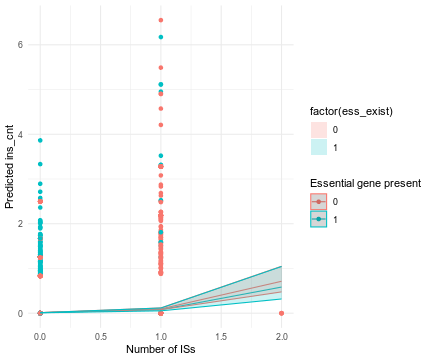

RObject{VecSxp}


In [78]:
R"""
tidied_data %>% mutate(ins_cnt.adj = ins_cnt/exp(offset)*(def.non_ess_bp*def.passages)) %>%
	ggplot(aes(x = is_cnt, color = factor(ess_exist))) +
	geom_point(aes(y = ins_cnt.adj)) +
	geom_line(data = new_data, aes(y = predicted, color = factor(ess_exist))) +
	geom_ribbon(data = new_data, aes(ymin = lower, ymax = upper, fill = factor(ess_exist)), alpha = 0.2) +
	labs(y = "Predicted ins_cnt", x = "Number of ISs", color = "Essential gene present") +
	theme_minimal()
"""